# Weather Trend Forecasting

## Advanced Assessment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

### Preprocessing

Parse dates since we know we"ll be doing time-series. Remove index column for redundancy

In [2]:
df = pd.read_csv("GlobalWeatherRepository.csv", parse_dates=["last_updated"], index_col=0)

df.sample(5)

,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
country,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Bosnia and Herzegovina,Sarajevo,43.8500,18.3833,Europe/Sarajevo,1774247400,2026-03-23 07:30:00,4.4,39.9,Overcast,2.2,3.6,76,ENE,1013.0,29.91,0.00,0.0,81,0,4.0,39.3,10.0,6.0,0.3,6.7,10.8,241.85,50.0,11.75,9.150,26.95,35.450,2,3,05:45 AM,06:02 PM,07:40 AM,No moonset,Waxing Crescent,19
Japan,Tokyo,35.6895,139.6917,Asia/Tokyo,1731142800,2024-11-09 18:00:00,16.8,62.2,Partly Cloudy,10.7,17.3,75,ENE,1028.0,30.36,0.00,0.0,48,59,16.8,62.2,10.0,6.0,0.0,13.7,22.1,603.10,31.0,67.34,61.605,44.77,65.860,3,5,06:11 AM,04:38 PM,12:46 PM,11:14 PM,First Quarter,47
Sweden,Stockholm,59.3333,18.0500,Europe/Stockholm,1767770100,2026-01-07 08:15:00,-4.7,23.5,Partly cloudy,4.5,7.2,256,WSW,1012.0,29.88,0.01,0.0,100,75,-8.0,17.7,10.0,6.0,0.0,9.4,15.1,209.85,38.0,11.05,1.550,6.35,7.950,1,1,08:40 AM,03:09 PM,09:06 PM,10:18 AM,Waning Gibbous,84
Bahamas,Nassau,25.0833,-77.3500,America/Nassau,1744103700,2025-04-08 05:15:00,24.2,75.6,Partly cloudy,15.9,25.6,168,SSE,1013.0,29.92,0.00,0.0,78,50,26.3,79.4,10.0,6.0,0.0,21.6,34.8,275.65,81.0,1.85,1.110,14.06,22.015,1,2,06:54 AM,07:29 PM,04:01 PM,04:32 AM,Waxing Gibbous,80
Democratic Republic of Congo,Kinshasa,-4.3000,15.3000,Africa/Brazzaville,1715868000,2024-05-16 15:00:00,32.0,89.6,Patchy light rain with thunder,16.1,25.9,160,SSE,1009.0,29.80,0.00,0.0,56,25,34.1,93.5,8.0,4.0,8.0,20.6,33.1,627.50,73.0,2.20,2.200,15.00,31.100,1,2,05:58 AM,05:53 PM,01:05 PM,12:34 AM,Waxing Gibbous,55


In [3]:
df.isnull().sum()

location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Nitrogen_dioxide    0
air_quality_Su

In [4]:
df = df.drop_duplicates()

### Feature Engineering

In [5]:
df["year"] = df["last_updated"].dt.year
df["month"] = df["last_updated"].dt.month
df["day"] = df["last_updated"].dt.day
df["day_of_week"] = df["last_updated"].dt.dayofweek
df["day_of_year"] = df["last_updated"].dt.dayofyear

# Cyclical encoding (To help the model to learn seasons for example)
df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

### Advanced EDA

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns

In [7]:
df[numeric_cols].describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination,year,month,day,day_of_week,day_of_year,doy_sin,doy_cos
count,136243.000000,136243.000000,1.362430e+05,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000,136243.000000
mean,19.210637,21.958390,1.746169e+09,21.272043,70.291445,8.014087,12.901054,168.802287,1014.067409,29.944797,0.134241,0.005088,66.651564,39.985107,22.124332,71.818294,9.506924,5.615723,3.317443,11.337425,18.247707,459.766636,58.025059,14.983222,10.328233,24.163994,48.311886,1.697871,2.602299,49.633383,2024.825349,6.612068,15.725630,3.009476,185.975947,-0.033530,0.022034
std,24.416230,65.787587,1.749808e+07,9.689266,17.440535,7.207274,11.595801,103.738812,10.338482,0.305250,0.562439,0.022231,23.876928,34.100539,11.592316,20.863798,2.691853,1.681853,3.548863,8.575863,13.801435,756.561760,30.727521,23.668713,35.552442,36.793845,148.923469,0.939645,2.441249,35.087041,0.669058,3.489477,8.793304,1.989596,106.849432,0.700467,0.712561
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,0.000000,0.000000,2.000000,0.000000,-36.700000,-34.000000,0.000000,0.000000,0.000000,2.200000,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000,2024.000000,1.000000,1.000000,0.000000,1.000000,-0.999991,-0.999963
25%,4.050300,-6.836100,1.731056e+09,16.000000,60.700000,3.800000,6.100000,80.000000,1010.000000,29.830000,0.000000,0.000000,51.000000,0.000000,16.000000,60.700000,10.000000,6.000000,0.100000,6.400000,10.200000,201.900000,38.000000,1.665000,1.110000,7.050000,9.990000,1.000000,1.000000,15.000000,2024.000000,3.000000,8.000000,1.000000,89.000000,-0.729558,-0.720667
50%,17.250000,23.236100,1.746176e+09,24.000000,75.100000,6.700000,10.800000,161.000000,1014.000000,29.930000,0.000000,0.000000,72.000000,30.000000,25.100000,77.200000,10.000000,6.000000,1.900000,9.500000,15.300000,293.850000,55.000000,5.600000,2.405000,14.150000,19.980000,1.000000,2.000000,49.000000,2025.000000,7.000000,16.000000,3.000000,190.000000,-0.051620,0.055917
75%,40.400000,49.882200,1.761293e+09,28.000000,82.400000,11.000000,17.600000,256.000000,1018.000000,30.060000,0.030000,0.000000,86.000000,75.000000,29.900000,85.900000,10.000000,6.000000,6.000000,15.000000,24.200000,459.850000,74.000000,17.390000,8.325000,27.750000,41.440000,2.000000,3.000000,84.000000,2025.000000,10.000000,23.000000,5.000000,279.000000,0.642055,0.726608
max,64.150000,179.220000,1.776494e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,42.240000,1.660000,100.000000,100.000000,51.200000,124.200000,32.000000,19.000000,16.300000,1845.700000,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000,2026.000000,12.000000,31.000000,6.000000,366.000000,0.999991,1.000000


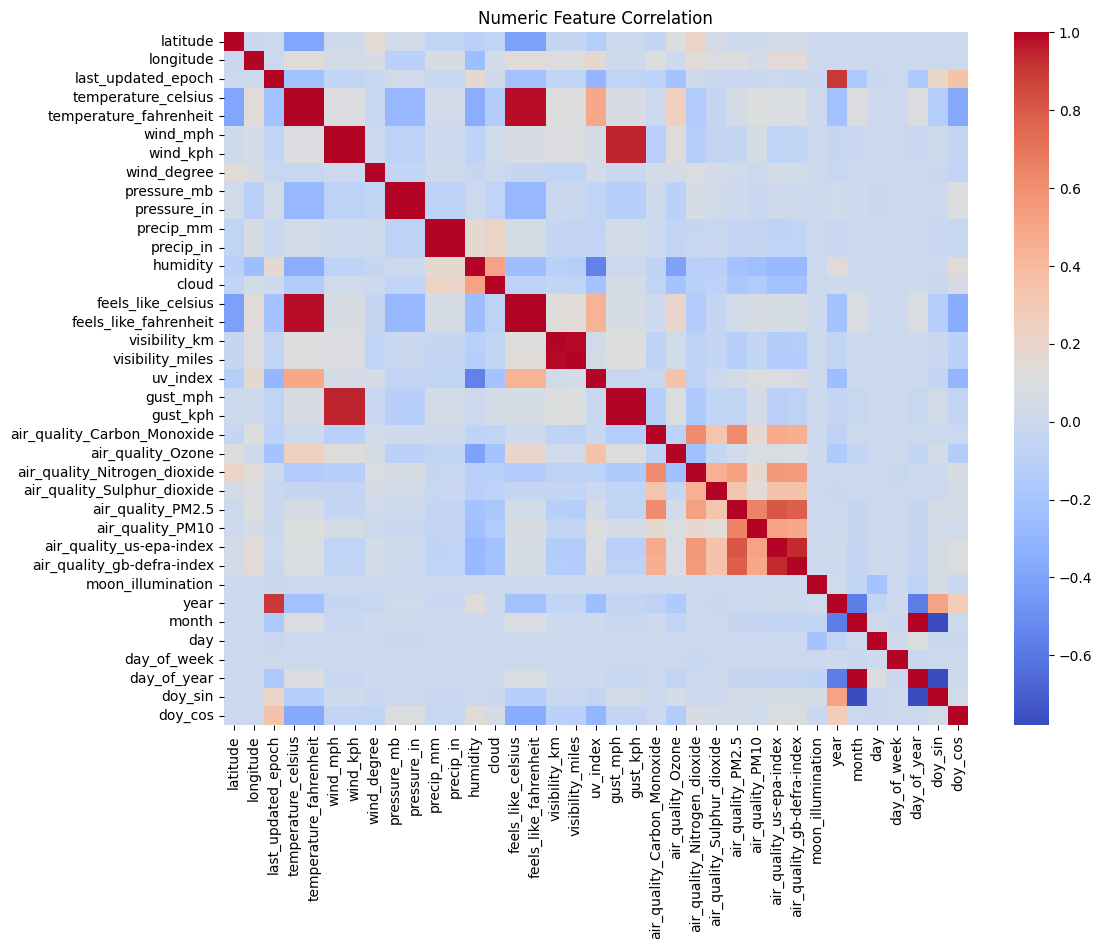

In [8]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Numeric Feature Correlation")
plt.show()

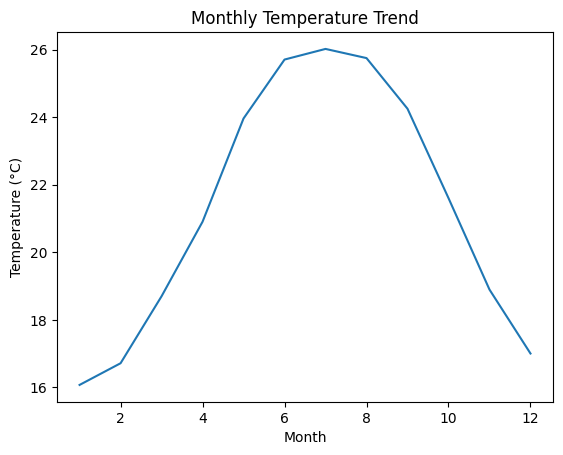

In [9]:
df.groupby("month")["temperature_celsius"].mean().plot(title="Monthly Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Anomaly Detection

In [10]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

I selected a subset of continuous environmental variables (temperature, wind speed, and particulate matter) that directly influence atmospheric conditions. This ensures the Isolation Forest focuses on meaningful physical deviations rather than noise or redundant signals.

In [11]:
features = ["temperature_celsius", "wind_mph", "air_quality_PM2.5", "air_quality_PM10"]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(contamination=0.03, random_state=42)
df["anomaly_iso"] = iso.fit_predict(X_scaled)

In [12]:
from scipy.stats import zscore

df["z_temp"] = np.abs(zscore(df["temperature_celsius"].fillna(0)))
df["anomaly_z"] = (df["z_temp"] > 3).astype(int)

In [13]:
# Add a flag if: Isolation Forest says it"s anomalous or Z-score says it"s extreme
df["anomaly_combined"] = ((df["anomaly_iso"] == -1) | (df["anomaly_z"] == 1)).astype(int)

In [14]:
df.sample(20)

,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,day,day_of_week,day_of_year,doy_sin,doy_cos,anomaly_iso,z_temp,anomaly_z,anomaly_combined
country,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Myanmar,Yangon,16.7833,96.1667,Asia/Yangon,1732265100,2024-11-22 15:15:00,32.3,90.1,Partly cloudy,5.4,8.6,11,NNE,1008.0,29.77,0.00,0.00,67,50,36.3,97.3,7.0,4.0,2.1,7.0,11.2,873.20,109.0,5.550,14.985,36.260,36.445,2,4,06:13 AM,05:30 PM,11:40 PM,11:59 AM,Waning Gibbous,63,2024,11,22,4,327,-0.608477,0.793572,1,1.138167,0,0
India,New Delhi,28.6000,77.2000,Asia/Kolkata,1735465500,2024-12-29 15:15:00,21.0,69.8,Sunny,7.6,12.2,302,WNW,1018.0,30.05,0.00,0.00,42,0,21.0,69.8,10.0,6.0,1.1,9.1,14.6,1707.55,89.0,43.660,56.795,177.415,179.265,5,10,07:13 AM,05:34 PM,05:48 AM,03:56 PM,Waning Crescent,5,2024,12,29,6,364,-0.017213,0.999852,-1,0.028077,0,1
Burkina Faso,Ouagadougou,12.3703,-1.5247,Africa/Ouagadougou,1746176400,2025-05-02 09:00:00,30.1,86.2,Partly Cloudy,8.1,13.0,185,S,1012.0,29.88,0.00,0.00,59,0,30.0,85.9,8.0,4.0,4.0,9.3,14.9,547.60,69.0,2.405,1.110,56.240,189.440,3,7,05:46 AM,06:20 PM,10:09 AM,11:30 PM,Waxing Crescent,24,2025,5,2,4,122,0.863142,-0.504961,1,0.911110,0,0
Netherlands,Amsterdam,52.3700,4.8900,Europe/Amsterdam,1724328000,2024-08-22 14:00:00,20.2,68.4,Sunny,20.6,33.1,210,SSW,1008.0,29.77,0.00,0.00,60,0,20.2,68.4,10.0,6.0,6.0,25.1,40.3,213.60,98.7,5.400,2.300,5.900,10.100,1,1,06:35 AM,08:50 PM,09:52 PM,10:06 AM,Waning Gibbous,93,2024,8,22,3,235,-0.785650,-0.618671,1,0.110643,0,0
Indonesia,Laos,-8.1826,114.3188,Asia/Jakarta,1739010600,2025-02-08 17:30:00,27.1,80.8,Patchy rain nearby,6.3,10.1,214,SW,1007.0,29.73,0.49,0.02,78,87,30.2,86.4,9.0,5.0,0.2,9.3,15.0,575.35,105.0,2.590,3.145,27.380,28.305,2,3,05:25 AM,05:49 PM,02:17 PM,01:08 AM,Waxing Gibbous,75,2025,2,8,5,39,0.622047,0.782980,1,0.601488,0,0
Kazakhstan,Astana,51.1811,71.4278,Asia/Almaty,1735209000,2024-12-26 15:30:00,-7.4,18.7,Partly Cloudy,6.5,10.4,182,S,1033.0,30.51,0.00,0.00,80,27,-12.3,9.9,10.0,6.0,0.2,11.9,19.2,1263.55,64.0,22.940,39.035,25.900,27.195,2,3,08:18 AM,04:12 PM,03:39 AM,12:47 PM,Waning Crescent,24,2024,12,26,3,361,-0.068802,0.997630,1,2.959166,0,0
Monaco,Monaco,43.7333,7.4167,Europe/Paris,1757144700,2025-09-06 09:45:00,24.3,75.7,Sunny,4.7,7.6,100,E,1020.0,30.12,0.00,0.00,65,25,25.7,78.2,10.0,6.0,0.9,5.4,8.7,246.05,65.0,12.025,0.925,10.175,14.985,1,1,07:00 AM,07:57 PM,07:31 PM,05:06 AM,Waxing Gibbous,96,2025,9,6,5,249,-0.910605,-0.413279,1,0.312508,0,0
Vietnam,Hanoi,21.0300,105.8500,Asia/Bangkok,1726401600,2024-09-15 19:00:00,31.1,88.0,Partly cloudy,7.4,11.9,145,SE,1001.0,29.56,0.60,0.02,75,25,41.6,106.8,7.0,4.0,1.0,14.0,22.6,590.15,201.0,6.475,69.930,94.905,137.455,4,10,05:44 AM,05:59 PM,04:05 PM,02:23 AM,Waxing Gibbous,86,2024,9,15,6,259,-0.967938,-0.251190,1,1.014318,0,0
Congo,Brazzaville,-4.2592,15.2847,Africa/Brazzaville,1730625300,2024-11-03 10:15:00,30.0,86.0,Patchy rain nearby,2.5,4.0,221,SW,1013.0,29.92,0.01,0.00,64,54,33.9,93.0,10.0,6.0,8.1,2.8,4.6,538.35,51.0,3.700,2.220,19.425,27.565,2,2,05:35 AM,05:51 PM,06:48 AM,07:29 PM,Waxing Crescent,2,2024,11,3,6,308,-0.831171,0.556017,1,0.900790,0,0


### Forecasting with Multiple Models

In [15]:
ts = df.set_index("last_updated")["temperature_celsius"].resample("D").mean().ffill()

def create_lag_features(series, lags=7):
    df_lag = pd.DataFrame(series)
    for i in range(1, lags+1):
        df_lag[f"lag_{i}"] = df_lag[series.name].shift(i)
    return df_lag.dropna()

lagged = create_lag_features(ts, lags=14)

In [16]:
train_size = int(len(lagged) * 0.8)

train = lagged.iloc[:train_size]
test = lagged.iloc[train_size:]

X_train = train.drop(columns=["temperature_celsius"])
y_train = train["temperature_celsius"]

X_test = test.drop(columns=["temperature_celsius"])
y_test = test["temperature_celsius"]

Random Forest

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [18]:
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)

    return mae

ARIMA

In [19]:
from statsmodels.tsa.arima.model import ARIMA

In [20]:
def arima_objective(trial):
    p = trial.suggest_int('p', 0, 3)
    d = trial.suggest_int('d', 0, 2)
    q = trial.suggest_int('q', 0, 3)

    try:
        model = ARIMA(ts, order=(p,d,q)).fit()
        pred = model.forecast(steps=len(y_test))
        return mean_absolute_error(y_test, pred)
    except:
        return float('inf')

Optuna Optimization

In [21]:
import optuna

/Users/benjaminkwan/coding_projects/weather_trend_forecasting/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
study = optuna.create_study(direction='minimize')
study.optimize(rf_objective, n_trials=30)

print("Best params:", study.best_params)
print("Best MAE:", study.best_value)

[I 2026-04-18 14:44:31,728] A new study created in memory with name: no-name-4df45682-2393-4616-86a6-4f78a75b801e
[I 2026-04-18 14:44:31,926] Trial 0 finished with value: 1.1210709105214667 and parameters: {'n_estimators': 219, 'max_depth': 21, 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 0 with value: 1.1210709105214667.
[I 2026-04-18 14:44:32,015] Trial 1 finished with value: 1.1859806409806541 and parameters: {'n_estimators': 102, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 5}. Best is trial 0 with value: 1.1210709105214667.
[I 2026-04-18 14:44:32,197] Trial 2 finished with value: 1.169209795119118 and parameters: {'n_estimators': 252, 'max_depth': 24, 'min_samples_split': 3, 'min_samples_leaf': 5}. Best is trial 0 with value: 1.1210709105214667.
[I 2026-04-18 14:44:32,443] Trial 3 finished with value: 1.1256663032939087 and parameters: {'n_estimators': 365, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 1}. Best is trial 0 with value: 

Best params: {'n_estimators': 396, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 2}
Best MAE: 1.1120767410588857


In [23]:
best_model = RandomForestRegressor(**study.best_params, random_state=42)
best_model.fit(X_train, y_train)

rf_pred = best_model.predict(X_test)

In [ ]:
arima_study = optuna.create_study(direction='minimize')
arima_study.optimize(arima_objective, n_trials=20)

print("Best ARIMA:", arima_study.best_params)

[I 2026-04-18 14:44:39,277] A new study created in memory with name: no-name-907a8017-1704-4c65-a4f0-16fa0c6f85bc
[I 2026-04-18 14:44:39,304] Trial 0 finished with value: 3.6547076688800333 and parameters: {'p': 0, 'd': 1, 'q': 2}. Best is trial 0 with value: 3.6547076688800333.
[I 2026-04-18 14:44:39,341] Trial 1 finished with value: 4.869436350675579 and parameters: {'p': 0, 'd': 0, 'q': 0}. Best is trial 0 with value: 3.6547076688800333.
[I 2026-04-18 14:44:39,354] Trial 2 finished with value: 3.8837291088152357 and parameters: {'p': 1, 'd': 1, 'q': 0}. Best is trial 0 with value: 3.6547076688800333.
[I 2026-04-18 14:44:39,507] Trial 3 finished with value: 3.260718106603798 and parameters: {'p': 2, 'd': 2, 'q': 2}. Best is trial 3 with value: 3.260718106603798.
[I 2026-04-18 14:44:39,577] Trial 4 finished with value: 4.300251504226474 and parameters: {'p': 3, 'd': 0, 'q': 0}. Best is trial 3 with value: 3.260718106603798.
/Users/benjaminkwan/coding_projects/weather_trend_forecasting

Best ARIMA: {'p': 2, 'd': 2, 'q': 3}


In [ ]:
best_arima = ARIMA(ts, order=(
    arima_study.best_params['p'],
    arima_study.best_params['d'],
    arima_study.best_params['q']
)).fit()

arima_pred = best_arima.forecast(steps=len(y_test))

print("ARIMA MAE:", mean_absolute_error(y_test, arima_pred))

ARIMA MAE: 3.22790552373505
Ensemble MAE: 1.6919723414656969


/Users/benjaminkwan/coding_projects/weather_trend_forecasting/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Ensemble Model

In [28]:
from sklearn.linear_model import LinearRegression

In [31]:
meta_X = pd.DataFrame({
    'rf': rf_pred,
    'arima': arima_pred[:len(rf_pred)]
})

meta_model = LinearRegression()
meta_model.fit(meta_X, y_test[:len(meta_X)])

stacked_pred = meta_model.predict(meta_X)

print("Stacked MAE:", mean_absolute_error(y_test[:len(stacked_pred)], stacked_pred))

Stacked MAE: 0.7485719038026538
